In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

DATA_PATH = "../../4 - ER unified/finalData_with_er.csv"
df = pd.read_csv(DATA_PATH)
# Plot style
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")

/var/folders/0g/pbpqnp6j47d2_qcp9yhz87ch0000gn/T/ipykernel_44458/2220527098.py:8: DtypeWarning: Columns (5,11,12,13,14,15,23,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


In [2]:
# Country field quality check for 2024 IG+TT
df_24_ct = df[
    (df["_year"] == 2024) &
    (df["_platform"].isin(["instagram", "tiktok"])) &
    (df["category_unified"].notna()) &
    (~df["category_unified"].isin(["Other", "UNMAPPED"]))
].copy()

print(f"Total 2024 IG+TT rows (post-filter): {len(df_24_ct):,}")
print()
print("Country NA rate by platform:")
print(df_24_ct.groupby("_platform")["_country"].apply(
    lambda x: x.isna().mean() * 100
).round(2))
print()
print(f"Unique countries: {df_24_ct['_country'].nunique()}")
print(f"Total NA rows: {df_24_ct['_country'].isna().sum()}")
print()
print("Top 15 countries by total accounts:")
print(df_24_ct["_country"].value_counts().head(15))
print()

# Critical for RQ2b: how many countries have BOTH IG and TT accounts (≥10 each)?
print("=== Dual-platform country check ===")
ct_count = df_24_ct.groupby(["_country", "_platform"]).size().unstack(fill_value=0)
print(f"\nCountries with ≥10 IG accounts: {(ct_count.get('instagram', 0) >= 10).sum()}")
print(f"Countries with ≥10 TT accounts: {(ct_count.get('tiktok', 0) >= 10).sum()}")
print(f"Countries with ≥10 in BOTH: {((ct_count.get('instagram', 0) >= 10) & (ct_count.get('tiktok', 0) >= 10)).sum()}")
print(f"\nTotal valid (country, platform) units (≥10 accounts): {(ct_count >= 10).values.sum()}")

Total 2024 IG+TT rows (post-filter): 7,601

Country NA rate by platform:
_platform
instagram    0.0
tiktok       0.0
Name: _country, dtype: float64

Unique countries: 60
Total NA rows: 0

Top 15 countries by total accounts:
_country
russia            163
australia         160
all-countries     159
canada            158
spain             158
philippines       158
germany           157
brazil            156
united-kingdom    149
mexico            148
france            147
south-africa      146
italy             146
netherlands       145
indonesia         140
Name: count, dtype: int64

=== Dual-platform country check ===

Countries with ≥10 IG accounts: 60
Countries with ≥10 TT accounts: 59
Countries with ≥10 in BOTH: 59

Total valid (country, platform) units (≥10 accounts): 119


In [3]:
# Check all-countries and other potential pseudo-country labels
print("=== Country label sanity check ===")
print("\nAll unique country values (sorted by frequency):")
country_counts = df_24_ct["_country"].value_counts()
print(country_counts.to_string())

# Suspicious labels: anything that's not a real country name
# Common HypeAuditor pseudo-labels: all-countries, world, global, etc.
suspicious = ["all-countries", "world", "global", "worldwide", "all"]
present_suspicious = [s for s in suspicious if s in country_counts.index]
print(f"\nSuspicious pseudo-country labels found: {present_suspicious}")

# Also check for unusual entries
print(f"\nCountry names with special characters or numbers:")
unusual = [c for c in country_counts.index 
           if not c.replace("-", "").replace(" ", "").isalpha()]
print(unusual if unusual else "None")

=== Country label sanity check ===

All unique country values (sorted by frequency):
_country
russia                  163
australia               160
all-countries           159
canada                  158
spain                   158
philippines             158
germany                 157
brazil                  156
united-kingdom          149
mexico                  148
france                  147
south-africa            146
italy                   146
netherlands             145
indonesia               140
argentina               139
poland                  138
south-korea             138
malaysia                135
denmark                 133
singapore               133
puerto-rico             133
slovakia                132
colombia                132
switzerland             131
belgium                 131
sweden                  130
norway                  130
portugal                128
peru                    128
finland                 127
turkey                  127
japan     

In [4]:
# ============================================================
# RQ2b: Platform vs Country - which dominates content ecosystem?
# Data: 2024 IG vs TikTok (filtered)
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# Step 1: Filter 2024 IG+TT data with valid category and country
# Exclude all-countries pseudo-label
df_rq2b = df[
    (df["_year"] == 2024) &
    (df["_platform"].isin(["instagram", "tiktok"])) &
    (df["category_unified"].notna()) &
    (~df["category_unified"].isin(["Other", "UNMAPPED"])) &
    (df["_country"].notna()) &
    (df["_country"] != "all-countries")
].copy()

print(f"Filtered rows: {len(df_rq2b):,}")
print(f"Unique countries: {df_rq2b['_country'].nunique()}")
print(f"\nAccounts per platform:")
print(df_rq2b["_platform"].value_counts())

Filtered rows: 7,442
Unique countries: 59

Accounts per platform:
_platform
instagram    5182
tiktok       2260
Name: count, dtype: int64


In [5]:
# Step 2: Build the profile matrix
# Each row = one (country, platform) unit
# Columns = 7 unified categories (share of accounts in each category)

# Count accounts per (country, platform, category)
counts = df_rq2b.groupby(
    ["_country", "_platform", "category_unified"]
).size().unstack(fill_value=0)

# Total accounts per unit (for filtering and normalization)
unit_totals = counts.sum(axis=1)

# Filter: keep only (country, platform) units with >= 10 accounts
MIN_ACCOUNTS = 10
valid_units = unit_totals[unit_totals >= MIN_ACCOUNTS].index
profile = counts.loc[valid_units]

# Normalize each row to proportions (sum to 1)
profile_pct = profile.div(profile.sum(axis=1), axis=0)

print(f"=== Profile matrix construction ===")
print(f"Total (country, platform) units before filter: {len(counts)}")
print(f"After filter (>={MIN_ACCOUNTS} accounts): {len(profile)}")
print(f"\nUnits per platform:")
print(profile.reset_index()["_platform"].value_counts())
print(f"\nFirst 5 rows of profile matrix (proportions):")
print(profile_pct.head().round(3))
print(f"\nProfile matrix shape: {profile_pct.shape}")

=== Profile matrix construction ===
Total (country, platform) units before filter: 117
After filter (>=10 accounts): 117

Units per platform:
_platform
instagram    59
tiktok       58
Name: count, dtype: int64

First 5 rows of profile matrix (proportions):
category_unified         Beauty&Fashion  Entertainment  Knowledge&Info  \
_country      _platform                                                  
afghanistan   instagram           0.278          0.074           0.056   
              tiktok              0.062          0.125           0.219   
aland-islands instagram           0.167          0.000           0.083   
              tiktok              0.153          0.051           0.017   
argentina     instagram           0.261          0.196           0.196   

category_unified         Lifestyle  Music  Sports  Tech&Gaming  
_country      _platform                                         
afghanistan   instagram      0.093  0.352   0.148        0.000  
              tiktok         

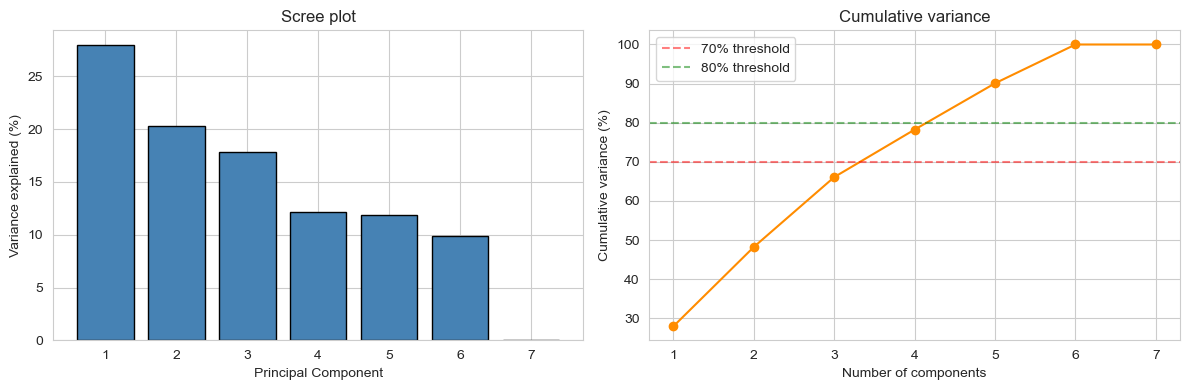


Variance explained:
  PC1: 27.95%  (cumulative: 27.95%)
  PC2: 20.28%  (cumulative: 48.23%)
  PC3: 17.86%  (cumulative: 66.10%)
  PC4: 12.15%  (cumulative: 78.25%)
  PC5: 11.84%  (cumulative: 90.08%)
  PC6:  9.92%  (cumulative: 100.00%)
  PC7:  0.00%  (cumulative: 100.00%)


In [6]:
# Step 3: PCA
# Standardize first (each category column to mean=0, std=1)
X = profile_pct.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit full PCA to see all eigenvalues
pca_full = PCA()
pca_full.fit(X_scaled)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: explained variance per component
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100,
            color="steelblue", edgecolor="black")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree plot")
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))

# Right: cumulative variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(range(1, len(cum_var) + 1), cum_var, "o-", color="darkorange")
axes[1].axhline(70, color="red", linestyle="--", alpha=0.5, label="70% threshold")
axes[1].axhline(80, color="green", linestyle="--", alpha=0.5, label="80% threshold")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance (%)")
axes[1].set_title("Cumulative variance")
axes[1].set_xticks(range(1, len(cum_var) + 1))
axes[1].legend()

plt.tight_layout()
plt.savefig("../plots/rq2b_scree.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nVariance explained:")
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:5.2f}%  (cumulative: {cum_var[i]:5.2f}%)")

Keeping 4 PCs (cumulative variance: 78.2%)


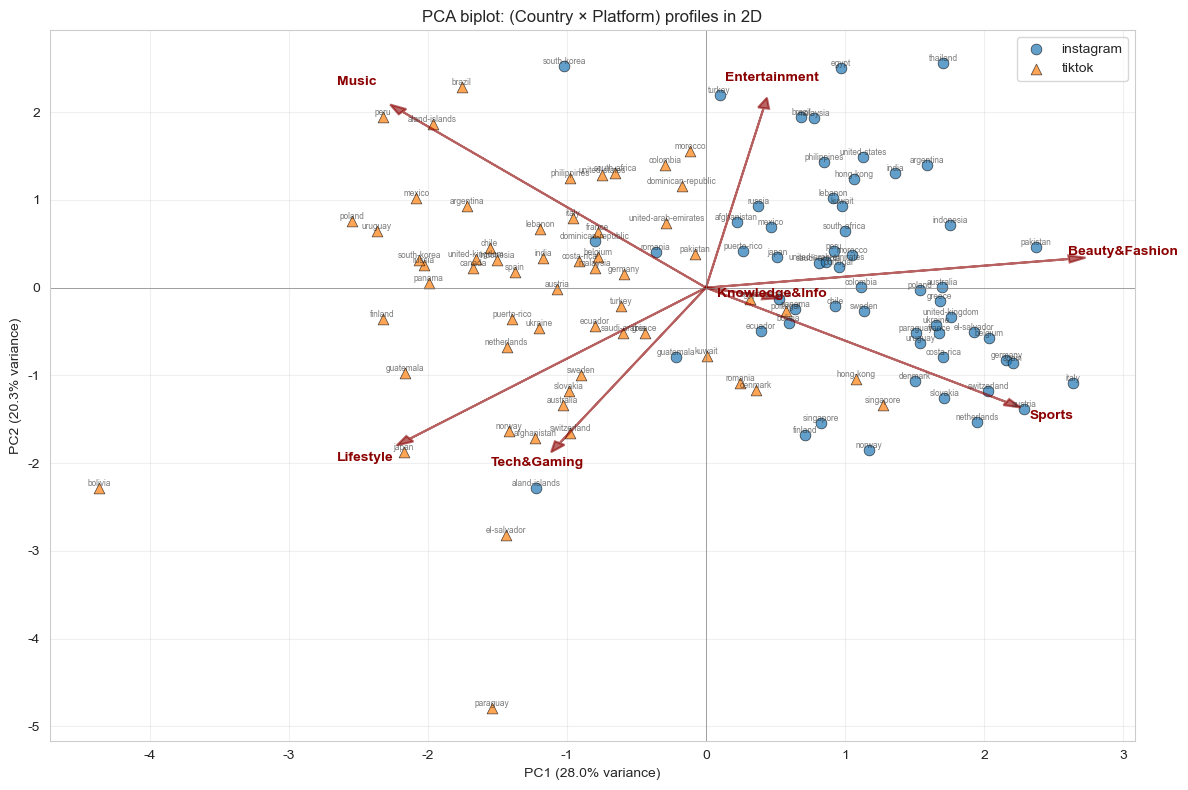

In [7]:
# Step 4: Keep PCs covering >=70% variance, but always at least 2 for visualization
n_components = max(2, int(np.argmax(cum_var >= 70)) + 1)
print(f"Keeping {n_components} PCs (cumulative variance: {cum_var[n_components-1]:.1f}%)")

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Extract metadata for plotting
meta = profile_pct.reset_index()[["_country", "_platform"]].copy()
meta["pc1"] = X_pca[:, 0]
meta["pc2"] = X_pca[:, 1]

# Category arrows (loadings) for biplot
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
cats = profile_pct.columns.tolist()

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter: shape by platform
for plat, marker in [("instagram", "o"), ("tiktok", "^")]:
    sub = meta[meta["_platform"] == plat]
    ax.scatter(sub["pc1"], sub["pc2"], marker=marker, s=60,
               alpha=0.7, edgecolor="black", linewidth=0.5,
               label=plat)
    # Annotate country names
    for _, row in sub.iterrows():
        ax.annotate(row["_country"], (row["pc1"], row["pc2"]),
                    fontsize=6, alpha=0.6, ha="center", va="bottom")

# Overlay category vectors (arrows)
arrow_scale = max(np.abs(X_pca[:, :2]).max(axis=0)) * 0.7
for i, cat in enumerate(cats):
    ax.arrow(0, 0,
             loadings[i, 0] * arrow_scale,
             loadings[i, 1] * arrow_scale,
             head_width=0.08, color="darkred", alpha=0.6, linewidth=1.5)
    ax.text(loadings[i, 0] * arrow_scale * 1.15,
            loadings[i, 1] * arrow_scale * 1.15,
            cat, fontsize=10, fontweight="bold",
            color="darkred", ha="center")

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA biplot: (Country × Platform) profiles in 2D")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/rq2b_pca_biplot.png", dpi=150, bbox_inches="tight")
plt.show()

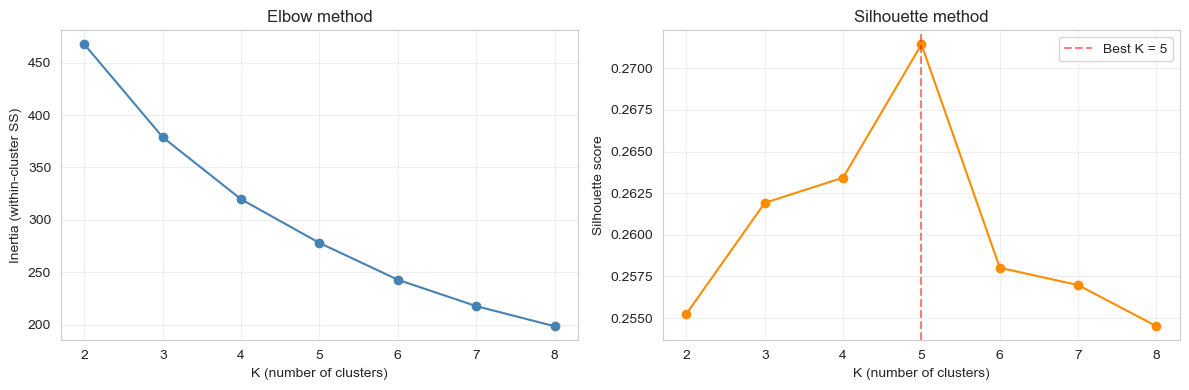


Silhouette scores per K:
  K=2: silhouette = 0.2553
  K=3: silhouette = 0.2619
  K=4: silhouette = 0.2634
  K=5: silhouette = 0.2714
  K=6: silhouette = 0.2580
  K=7: silhouette = 0.2570
  K=8: silhouette = 0.2545

Best K by silhouette: 5


In [8]:
# Step 5: Choose K for K-means using elbow + silhouette
# Use the PCA-reduced features for clustering
X_cluster = X_pca

k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, "o-", color="steelblue")
axes[0].set_xlabel("K (number of clusters)")
axes[0].set_ylabel("Inertia (within-cluster SS)")
axes[0].set_title("Elbow method")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouettes, "o-", color="darkorange")
axes[1].set_xlabel("K (number of clusters)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette method")
axes[1].grid(True, alpha=0.3)

# Best K by silhouette
best_k = list(k_range)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.5,
                label=f"Best K = {best_k}")
axes[1].legend()

plt.tight_layout()
plt.savefig("../plots/rq2b_choose_k.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSilhouette scores per K:")
for k, s in zip(k_range, silhouettes):
    print(f"  K={k}: silhouette = {s:.4f}")
print(f"\nBest K by silhouette: {best_k}")

In [9]:
# Step 6: Run K-means with chosen K and compute ARI vs platform/country
K = best_k  # use the silhouette-optimal K; you can override manually if needed

km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_cluster)
meta["cluster"] = cluster_labels

# True labels: platform (binary), country (multi-class)
platform_labels = meta["_platform"].values
country_labels = meta["_country"].values

# ARI: how well does cluster align with platform vs country?
ari_platform = adjusted_rand_score(platform_labels, cluster_labels)
ari_country = adjusted_rand_score(country_labels, cluster_labels)

print(f"=== ARI scores (K={K}) ===")
print(f"ARI vs platform: {ari_platform:.4f}")
print(f"ARI vs country:  {ari_country:.4f}")
print(f"\nInterpretation:")
print(f"  ARI = 0   ~ random partition")
print(f"  ARI = 1   ~ perfect match")
print(f"  ARI < 0   ~ worse than random")
print(f"\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

=== ARI scores (K=5) ===
ARI vs platform: 0.2803
ARI vs country:  -0.0106

Interpretation:
  ARI = 0   ~ random partition
  ARI = 1   ~ perfect match
  ARI < 0   ~ worse than random

Cluster sizes:
0    25
1    12
2    38
3    31
4    11
Name: count, dtype: int64


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/metrics/cluster/_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


In [10]:
# Step 7: Within-country consistency check
# For each country, are its IG unit and TT unit in the same cluster or different?

# Pivot: country x platform -> cluster
country_clusters = meta.pivot(index="_country", columns="_platform", values="cluster")

# Keep only countries with both platforms (which is all 59)
both = country_clusters.dropna()
same_cluster = (both["instagram"] == both["tiktok"]).sum()
diff_cluster = (both["instagram"] != both["tiktok"]).sum()
total = len(both)

print(f"=== Within-country platform consistency ===")
print(f"Total dual-platform countries: {total}")
print(f"  IG and TT in SAME cluster: {same_cluster} ({same_cluster/total*100:.1f}%)")
print(f"  IG and TT in DIFFERENT clusters: {diff_cluster} ({diff_cluster/total*100:.1f}%)")

# Cross-tab: how do IG units and TT units distribute across clusters?
print("\n=== Cluster x Platform cross-tab ===")
print(pd.crosstab(meta["_platform"], meta["cluster"]))

=== Within-country platform consistency ===
Total dual-platform countries: 58
  IG and TT in SAME cluster: 5 (8.6%)
  IG and TT in DIFFERENT clusters: 53 (91.4%)

=== Cluster x Platform cross-tab ===
cluster     0   1   2   3  4
_platform                   
instagram  17   1   3  29  9
tiktok      8  11  35   2  2


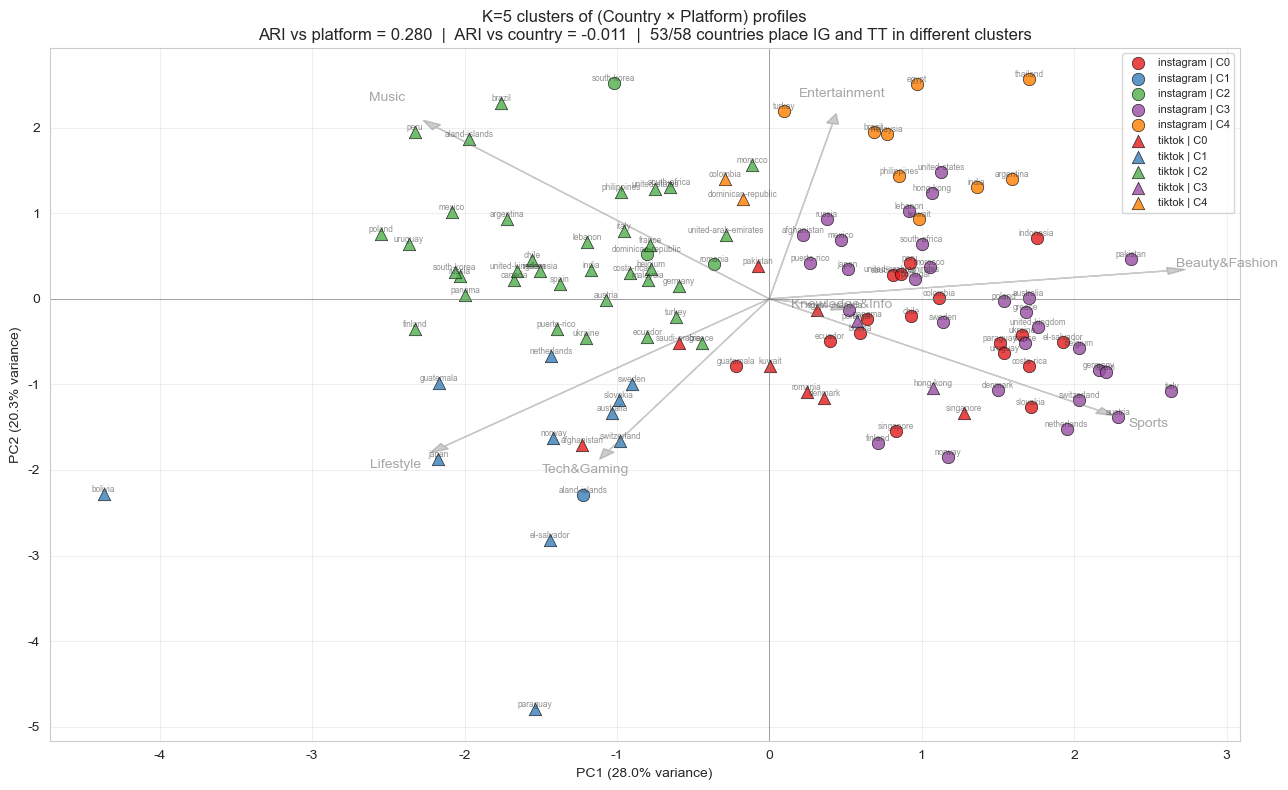


RQ2b FINAL SUMMARY
Data: 2024 IG vs TikTok
(Country, platform) units analyzed: 117
Number of countries: 59
Number of platforms: 2

Clustering:
  PCs used: 4 (covering 78.2% variance)
  K: 5 (chosen by silhouette)

Key metrics:
  ARI vs platform: 0.2803  <-- platform explains cluster structure
  ARI vs country:  -0.0106  <-- country does NOT explain cluster structure

Within-country diagnostic:
  53/58 dual-platform countries place IG and TT in DIFFERENT clusters (91.4%)

Conclusion: platform > country in shaping content ecosystem


In [11]:
# Step 8: Final visualization - PCA scatter colored by cluster, shaped by platform
fig, ax = plt.subplots(figsize=(13, 8))

cluster_palette = sns.color_palette("Set1", n_colors=K)

for plat, marker in [("instagram", "o"), ("tiktok", "^")]:
    sub = meta[meta["_platform"] == plat]
    for c in range(K):
        sub_c = sub[sub["cluster"] == c]
        ax.scatter(sub_c["pc1"], sub_c["pc2"],
                   marker=marker, s=80,
                   color=cluster_palette[c],
                   alpha=0.8, edgecolor="black", linewidth=0.5,
                   label=f"{plat} | C{c}" if len(sub_c) > 0 else None)

# Annotate
for _, row in meta.iterrows():
    ax.annotate(row["_country"], (row["pc1"], row["pc2"]),
                fontsize=6, alpha=0.5, ha="center", va="bottom")

# Category arrows
for i, cat in enumerate(cats):
    ax.arrow(0, 0,
             loadings[i, 0] * arrow_scale,
             loadings[i, 1] * arrow_scale,
             head_width=0.08, color="gray", alpha=0.4, linewidth=1)
    ax.text(loadings[i, 0] * arrow_scale * 1.15,
            loadings[i, 1] * arrow_scale * 1.15,
            cat, fontsize=10, color="gray", ha="center", alpha=0.7)

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title(
    f"K={K} clusters of (Country × Platform) profiles\n"
    f"ARI vs platform = {ari_platform:.3f}  |  "
    f"ARI vs country = {ari_country:.3f}  |  "
    f"{diff_cluster}/{total} countries place IG and TT in different clusters"
)
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/rq2b_final.png", dpi=150, bbox_inches="tight")
plt.show()

# Print final summary
print("\n" + "="*60)
print("RQ2b FINAL SUMMARY")
print("="*60)
print(f"Data: 2024 IG vs TikTok")
print(f"(Country, platform) units analyzed: {len(meta)}")
print(f"Number of countries: {meta['_country'].nunique()}")
print(f"Number of platforms: {meta['_platform'].nunique()}")
print(f"\nClustering:")
print(f"  PCs used: {n_components} (covering {cum_var[n_components-1]:.1f}% variance)")
print(f"  K: {K} (chosen by silhouette)")
print(f"\nKey metrics:")
print(f"  ARI vs platform: {ari_platform:.4f}  <-- platform explains cluster structure")
print(f"  ARI vs country:  {ari_country:.4f}  <-- country does NOT explain cluster structure")
print(f"\nWithin-country diagnostic:")
print(f"  {diff_cluster}/{total} dual-platform countries place IG and TT in DIFFERENT clusters "
      f"({diff_cluster/total*100:.1f}%)")
print(f"\nConclusion: platform > country in shaping content ecosystem")

ARI platform=0.2803  country=-0.0106

===== Cluster profiles =====

Cluster 0  (n=25, platform: {'instagram': 17, 'tiktok': 8})
  top categories: Beauty&Fashion 27%, Knowledge&Info 20%, Music 15%

Cluster 1  (n=12, platform: {'tiktok': 11, 'instagram': 1})
  top categories: Lifestyle 28%, Music 23%, Beauty&Fashion 15%

Cluster 2  (n=38, platform: {'tiktok': 35, 'instagram': 3})
  top categories: Music 41%, Beauty&Fashion 18%, Lifestyle 14%

Cluster 3  (n=31, platform: {'instagram': 29, 'tiktok': 2})
  top categories: Beauty&Fashion 34%, Music 22%, Sports 22%

Cluster 4  (n=11, platform: {'instagram': 9, 'tiktok': 2})
  top categories: Beauty&Fashion 28%, Music 26%, Entertainment 19%

[saved] rq2b_cluster_profiles.png

===== Permutation ARI =====


/opt/homebrew/anaconda3/lib/python3.13/site-packages/sklearn/metrics/cluster/_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


Observed ARI vs platform = 0.2803
Null distribution mean=0.0000, 95th percentile=0.0191
permutation p = 0.0002
[saved] rq2b_permutation_ari.png


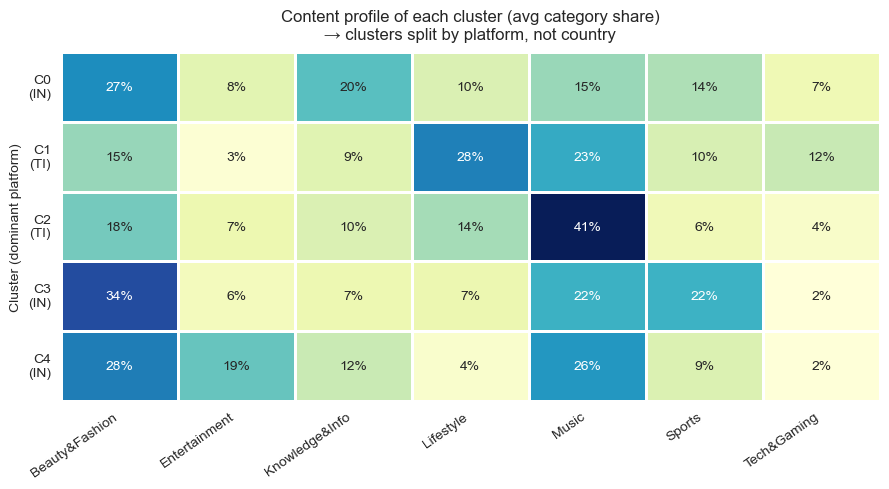

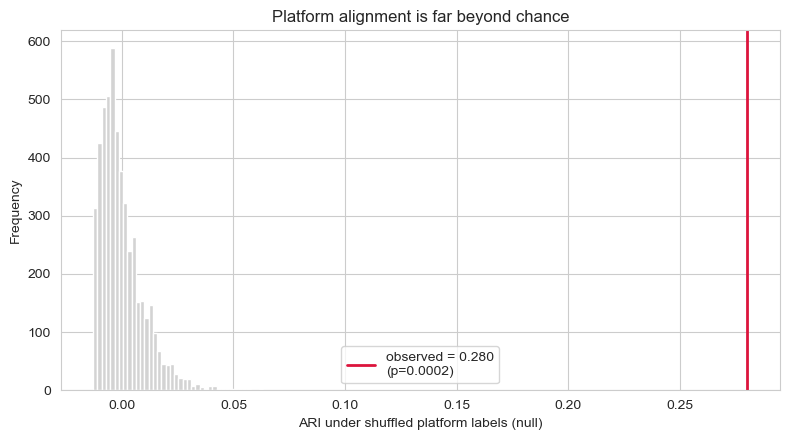

In [12]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

df = pd.read_csv("../../4 - ER unified/finalData_with_er.csv", low_memory=False)

# ===== Reproduce the RQ2b pipeline up to `meta` =====
df_rq2b = df[(df["_year"]==2024) & (df["_platform"].isin(["instagram","tiktok"]))
    & (df["category_unified"].notna()) & (~df["category_unified"].isin(["Other","UNMAPPED"]))
    & (df["_country"].notna()) & (df["_country"]!="all-countries")].copy()

counts = df_rq2b.groupby(["_country","_platform","category_unified"]).size().unstack(fill_value=0)
profile = counts.loc[counts.sum(axis=1)[counts.sum(axis=1)>=10].index]
profile_pct = profile.div(profile.sum(axis=1), axis=0)
cats = profile_pct.columns.tolist()

X_scaled = StandardScaler().fit_transform(profile_pct.values)
cum = np.cumsum(PCA().fit(X_scaled).explained_variance_ratio_)*100
n_comp = max(2, int(np.argmax(cum>=70))+1)
X_pca = PCA(n_components=n_comp).fit_transform(X_scaled)

K = 5
cluster_labels = KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(X_pca)
meta = profile_pct.reset_index()[["_country","_platform"]].copy()
meta["cluster"] = cluster_labels

ari_plat = adjusted_rand_score(meta["_platform"], cluster_labels)
ari_ctry = adjusted_rand_score(meta["_country"], cluster_labels)
print(f"ARI platform={ari_plat:.4f}  country={ari_ctry:.4f}")

# ============================================================
# Analysis 1: Cluster profiling -- platform composition + mean category profile per cluster
# ============================================================
print("\n===== Cluster profiles =====")
prof_idx = profile_pct.reset_index()
prof_idx["cluster"] = cluster_labels

for c in range(K):
    members = meta[meta["cluster"]==c]
    plat_mix = members["_platform"].value_counts().to_dict()
    # Mean category share across all units in this cluster
    avg_prof = prof_idx[prof_idx["cluster"]==c][cats].mean().sort_values(ascending=False)
    top3 = avg_prof.head(3)
    print(f"\nCluster {c}  (n={len(members)}, platform: {plat_mix})")
    print(f"  top categories: " + ", ".join([f"{k} {v:.0%}" for k,v in top3.items()]))

# heatmap: cluster x mean category share
cluster_cat = prof_idx.groupby("cluster")[cats].mean()
fig, ax = plt.subplots(figsize=(9,5))
sns.heatmap(cluster_cat, annot=True, fmt=".0%", cmap="YlGnBu", cbar=False,
            linewidths=1, linecolor="white", ax=ax, annot_kws={"size":10})
# Annotate the dominant platform of each cluster
plat_dom = meta.groupby("cluster")["_platform"].agg(lambda x: x.value_counts().index[0])
ax.set_yticklabels([f"C{c}\n({plat_dom[c][:2].upper()})" for c in range(K)], rotation=0)
ax.set_title("Content profile of each cluster (avg category share)\n"
             "→ clusters split by platform, not country", fontsize=12, pad=10)
ax.set_xlabel(""); ax.set_ylabel("Cluster (dominant platform)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("../plots/rq2b_cluster_profiles.png", dpi=150, bbox_inches="tight")
print("\n[saved] rq2b_cluster_profiles.png")

# ============================================================
# Analysis 2: Permutation test -- is ARI vs platform significantly above chance?
# ============================================================
print("\n===== Permutation ARI =====")
rng = np.random.default_rng(42)
B = 5000
null_ari = np.empty(B)
plat = meta["_platform"].values
for b in range(B):
    null_ari[b] = adjusted_rand_score(rng.permutation(plat), cluster_labels)
p_val = (np.sum(null_ari >= ari_plat) + 1) / (B + 1)
print(f"Observed ARI vs platform = {ari_plat:.4f}")
print(f"Null distribution mean={null_ari.mean():.4f}, 95th percentile={np.percentile(null_ari,95):.4f}")
print(f"permutation p = {p_val:.4f}")

fig, ax = plt.subplots(figsize=(8,4.5))
ax.hist(null_ari, bins=50, color="lightgray", edgecolor="white")
ax.axvline(ari_plat, color="crimson", lw=2,
           label=f"observed = {ari_plat:.3f}\n(p={p_val:.4f})")
ax.set_xlabel("ARI under shuffled platform labels (null)")
ax.set_ylabel("Frequency")
ax.set_title("Platform alignment is far beyond chance", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("../plots/rq2b_permutation_ari.png", dpi=150, bbox_inches="tight")
print("[saved] rq2b_permutation_ari.png")